# **Titanic project**

**Wymagania dotyczące projektu**

https://docs.google.com/document/d/1J4irYjynwelzo1bTSVOt5rg5Fvbdm239UH1M9cAyx04/edit?userstoinvite=jakub.bednarczyk%40edukacja.uwm.edu.pl&sharingaction=manageaccess&role=reader&tab=t.0


IMPORTS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# **1. Opis problemu**

**a) Opis dostępu do danych / sposób ich pozyskania**

Dane wykorzystane w projekcie pochodzą ze zbioru Titanic, który jest publicznie dostępny na platformie Kaggle jako Titanic Dataset.

Zbiór danych zawiera informacje o pasażerach statku RMS Titanic, który zatonął w wyniku kolizji z górą lodową w 1912 roku. Dane obejmują zarówno informacje demograficzne pasażerów, jak i szczegóły dotyczące ich podróży.

Dane można pobrać bezpośrednio ze strony Kaggle lub załadować do środowiska Google Colab jako plik CSV.

https://www.kaggle.com/datasets/yasserh/titanic-dataset


**b) Opis danych, w szczególności znaczenie atrybutów**

Zbiór danych zawiera następujące atrybuty:

**PassengerId** – unikalny identyfikator pasażera

**Survived** – zmienna docelowa (0 – nie przeżył, 1 – przeżył)

**Pclass** – klasa biletu (1 – wyższa, 2 – średnia, 3 – niższa)

**Name** – imię i nazwisko pasażera

**Sex** – płeć pasażera

**Age** – wiek pasażera

**SibSp** – liczba rodzeństwa / małżonków na pokładzie

**Parch** – liczba rodziców / dzieci na pokładzie

**Ticket** – numer biletu

**Fare** – opłata za bilet

**Cabin** – numer kabiny (często brak danych)

**Embarked** – port zaokrętowania (C – Cherbourg, Q – Queenstown, S – Southampton)

Niektóre zmienne zawierają brakujące wartości (np. Age, Cabin), co wymaga ich odpowiedniego przetworzenia.

**c) Definicja problemu: klasyfikacja / regresja**

Rozważany problem jest problemem klasyfikacji binarnej.

Celem jest zbudowanie modelu uczenia maszynowego, który na podstawie dostępnych cech pasażera będzie w stanie przewidzieć, czy dana osoba przeżyła katastrofę (Survived = 1) czy nie (Survived = 0).

**d) Znaczenie problemu**

Analiza danych związanych z katastrofą Titanica ma znaczenie zarówno historyczne, jak i edukacyjne.

Z punktu widzenia uczenia maszynowego, zbiór ten stanowi klasyczny przykład problemu klasyfikacyjnego, który pozwala przećwiczyć pełny proces analizy danych:

eksplorację danych (EDA),
przetwarzanie danych (data preprocessing),
budowę i ocenę modeli,
optymalizację hiperparametrów.

Dodatkowo projekt pozwala zrozumieć, które czynniki (np. płeć, wiek, klasa biletu) miały największy wpływ na przeżycie pasażerów.

# **2. Opis eksperymentu**

## **a) Analiza eksploracyjna danych**




**Wczytanie danych**

W pierwszym kroku dane zostaną wczytane do obiektu typu DataFrame z wykorzystaniem biblioteki pandas.

In [ ]:
path: str = '/content/drive/MyDrive/Colab Notebooks/Titanic-Dataset.csv'

df: pd.DataFrame = pd.read_csv(path)

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**Podgląd danych**

W celu wyświetlenia pierwszych wierszy zbioru danych wykorzystano metodę head.

In [ ]:
df.head(n=5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Informacje o danych**

Funkcja `info()` pozwala sprawdzić strukturę danych, typy kolumn oraz liczbę brakujących wartości.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Analiza struktury danych za pomocą metody `info()` pokazuje, że zbiór zawiera 891 rekordów oraz 12 kolumn o różnych typach danych (liczbowe oraz kategoryczne).

Większość zmiennych nie zawiera brakujących wartości, jednak w niektórych kolumnach występują luki danych:
- `Age` – 177 brakujących wartości,
- `Cabin` – znaczna liczba braków (687),
- `Embarked` – 2 brakujące wartości.

Obecność brakujących danych wskazuje na konieczność ich odpowiedniego przetworzenia w dalszych etapach projektu (np. imputacja lub usunięcie kolumny `Cabin`).

Zmienna docelowa `Survived` jest poprawnie zdefiniowana jako typ całkowity (`int64`), co jest zgodne z problemem klasyfikacji binarnej.

Zbiór danych jest typowy dla problemów klasyfikacji binarnej i wymaga etapów oczyszczania oraz przygotowania przed budową modelu.

**Statystyki opisowe**

Podstawowe statystyki dla zmiennych numerycznych zostały obliczone za pomocą metody `describe()`.

In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Analiza statystyk opisowych pokazuje rozkład zmiennych numerycznych w zbiorze danych.

W przypadku zmiennej `Age` średni wiek pasażerów wynosi około 29–30 lat, jednak widoczna jest duża zmienność wartości (od niemowląt do osób starszych). Oznacza to szeroką rozpiętość wiekową pasażerów.

Zmienne `SibSp` oraz `Parch` wskazują, że większość pasażerów podróżowała samotnie lub z niewielką liczbą członków rodziny.

Wartość `Fare` wykazuje duże zróżnicowanie, co sugeruje istotne różnice w klasach biletów i statusie ekonomicznym pasażerów.

Zmienna docelowa `Survived` potwierdza nierównomierny rozkład klas (więcej osób nie przeżyło katastrofy).

**Braki danych**

W celu sprawdzenia brakujących wartości wykorzystano metodę `isnull()`.

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Analiza brakujących wartości wskazuje, że problem ten dotyczy kilku kluczowych zmiennych.

Najwięcej braków występuje w kolumnie `Cabin`, co czyni ją mało użyteczną w obecnej formie bez dodatkowego przetwarzania.

W zmiennej `Age` występuje znacząca liczba braków, co może wpływać na jakość modeli predykcyjnych i wymaga zastosowania metod imputacji (np. średnia, mediana lub modele predykcyjne).

Kolumna `Embarked` zawiera jedynie pojedyncze brakujące wartości, które można łatwo uzupełnić dominującą kategorią.

Obecność braków danych wskazuje na konieczność etapu preprocessing przed budową modelu uczenia maszynowego.

Korzystając również z funkcji `info()` widzieliśmy już wcześniej obecność brakujących danych

**Sprawdzanie liczby duplikatów wierszy**

In [ ]:
print(df.duplicated().sum())

0


**Analiza zmiennej docelowej**

Zmienna `Survived` określa, czy pasażer przeżył katastrofę (0 – nie przeżył, 1 – przeżył).

In [ ]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


**Analiza zmiennej `Sex`**

Sprawdzono zależność między płcią a przeżyciem pasażerów (0 – nie przeżył, 1 – przeżył).

In [ ]:
df[['Sex', 'Survived']].value_counts()

,,count
Sex,Survived,
male,0,468
female,1,233
male,1,109
female,0,81


Wyniki wskazują, że kobiety miały znacznie większe prawdopodobieństwo przeżycia niż mężczyźni. W przypadku mężczyzn liczba osób, które nie przeżyły katastrofy, była zdecydowanie wyższa niż liczba ocalałych.

Otrzymane wyniki potwierdzają istotny wpływ płci na przeżywalność pasażerów Titanica.

Wizualizacja: Przeżywalność według płci

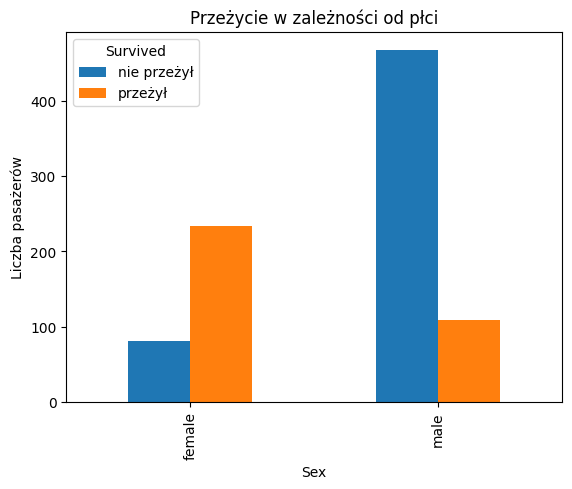

In [ ]:
ax = df.groupby(['Sex', 'Survived']).size().unstack()

ax = ax.rename(columns={
    0: 'nie przeżył',
    1: 'przeżył'
})

ax.plot(kind='bar')

plt.title('Przeżycie w zależności od płci')
plt.ylabel('Liczba pasażerów')
plt.xlabel('Sex')
plt.legend(title='Survived')

plt.show()

**Analiza zmiennej `Pclass`**

Przeanalizowano wpływ klasy biletu na przeżywalność (0 – nie przeżył, 1 – przeżył).

In [ ]:
df.groupby(['Pclass', 'Survived']).size()

Pclass  Survived
1       0            80
        1           136
2       0            97
        1            87
3       0           372
        1           119
dtype: int64

Przeanalizowano wpływ klasy biletu na przeżywalność pasażerów. Wyniki pokazują, że pasażerowie z 1 klasy mieli znacznie większe szanse na przeżycie niż osoby z 2 i 3 klasy.

Wizualizacja: Przeżywalność według klasy biletu

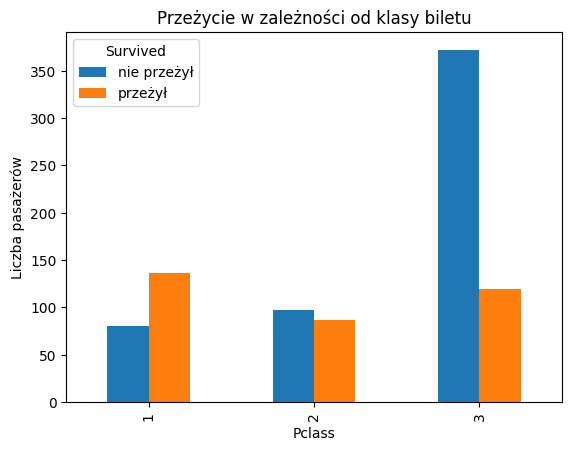

In [ ]:
ax = df.groupby(['Pclass', 'Survived']).size().unstack()

ax = ax.rename(columns={
    0: 'nie przeżył',
    1: 'przeżył'
})

ax.plot(kind='bar')

plt.title('Przeżycie w zależności od klasy biletu')
plt.xlabel('Pclass')
plt.ylabel('Liczba pasażerów')

plt.legend(title='Survived')

plt.show()

**Operacje pomocnicze:**

Operacje pomocnicze zostały wykorzystane do lepszego poznania struktury danych oraz analizy wartości skrajnych. Ułatwiły one zrozumienie rozkładu danych i wspierały proces eksploracyjnej analizy danych (EDA).

**Rankingowanie (nlargest / nsmallest)**

Ranking pasażerów według wieku

In [ ]:
df.nlargest(10, 'Age')[['Name', 'Age', 'Sex', 'Survived']].head()

,Name,Age,Sex,Survived
630,"Barkworth, Mr. Algernon Henry Wilson",80.0,male,1
851,"Svensson, Mr. Johan",74.0,male,0
96,"Goldschmidt, Mr. George B",71.0,male,0
493,"Artagaveytia, Mr. Ramon",71.0,male,0
116,"Connors, Mr. Patrick",70.5,male,0


In [ ]:
df.nsmallest(10, 'Age')[['Name', 'Age', 'Sex', 'Survived']].head()

,Name,Age,Sex,Survived
803,"Thomas, Master. Assad Alexander",0.42,male,1
755,"Hamalainen, Master. Viljo",0.67,male,1
469,"Baclini, Miss. Helene Barbara",0.75,female,1
644,"Baclini, Miss. Eugenie",0.75,female,1
78,"Caldwell, Master. Alden Gates",0.83,male,1


Operacje rankingowe zostały wykorzystane w celu identyfikacji pasażerów o skrajnych wartościach cech, takich jak wiek.

Dzięki temu możliwe jest zrozumienie struktury danych oraz sprawdzenie, jakie osoby znajdują się na ekstremach rozkładu (najmłodsi i najstarsi pasażerowie).

Analiza ta pozwala lepiej poznać charakter zbioru danych i wykryć potencjalne nietypowe obserwacje.

**Sortowanie**

Sortowanie według wieku i opłaty za bilet

In [ ]:
df.sort_values(['Age', 'Fare'], ascending=False)[['Name', 'Age', 'Fare', 'Survived']].head(10)

,Name,Age,Fare,Survived
630,"Barkworth, Mr. Algernon Henry Wilson",80.0,30.0000,1
851,"Svensson, Mr. Johan",74.0,7.7750,0
493,"Artagaveytia, Mr. Ramon",71.0,49.5042,0
96,"Goldschmidt, Mr. George B",71.0,34.6542,0
116,"Connors, Mr. Patrick",70.5,7.7500,0
745,"Crosby, Capt. Edward Gifford",70.0,71.0000,0
672,"Mitchell, Mr. Henry Michael",70.0,10.5000,0
33,"Wheadon, Mr. Edward H",66.0,10.5000,0
54,"Ostby, Mr. Engelhart Cornelius",65.0,61.9792,0
456,"Millet, Mr. Francis Davis",65.0,26.5500,0


Sortowanie danych według wieku oraz opłaty za bilet zostało wykonane w celu analizy zależności pomiędzy wiekiem pasażerów a ich statusem ekonomicznym (Fare).

Operacja ta pozwala uporządkować dane i lepiej zrozumieć ich strukturę, co jest istotne w dalszej analizie eksploracyjnej.

**Agregacja (groupby)**

**Średnia przeżywalność według płci**

Analiza średniej przeżywalności według płci została wykonana w celu sprawdzenia wpływu tej cechy na szanse przeżycia.

Pozwala to określić, czy płeć była istotnym czynnikiem decyzyjnym podczas katastrofy.


In [ ]:
df.groupby('Sex').agg({'Survived': 'mean'})

,Survived
Sex,
female,0.742038
male,0.188908


Wizualizacja

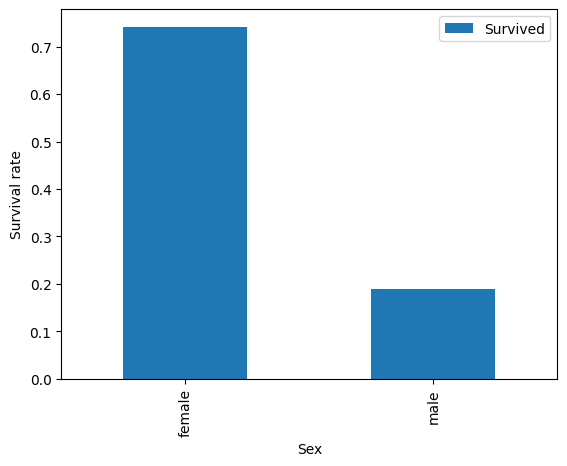

In [ ]:
ax = df.groupby('Sex').agg({'Survived': 'mean'}).plot.bar()
ax.set_ylabel('Survival rate')
plt.show()

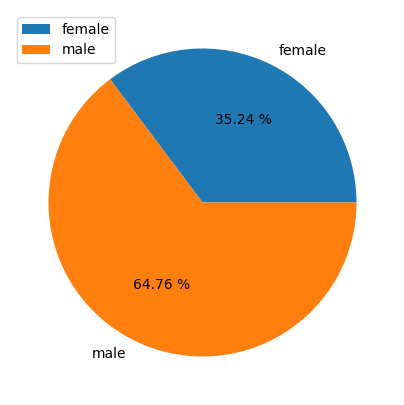

In [ ]:
ax = df.groupby('Sex').agg({'Sex': 'count'}).plot.pie(
    subplots=True,
    autopct='%.2f %%',
    ylabel='',
    figsize=(5, 5)
)

plt.show()

**Średnia przeżywalność według klasy**

Analiza przeżywalności w zależności od klasy biletu została przeprowadzona w celu oceny wpływu statusu społeczno-ekonomicznego pasażerów na ich szanse przeżycia.

Wyniki tej analizy pomagają zidentyfikować, czy pasażerowie z wyższych klas mieli uprzywilejowaną pozycję.

In [ ]:
df.groupby('Pclass').agg({'Survived': 'mean'})

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


Wizualizacja

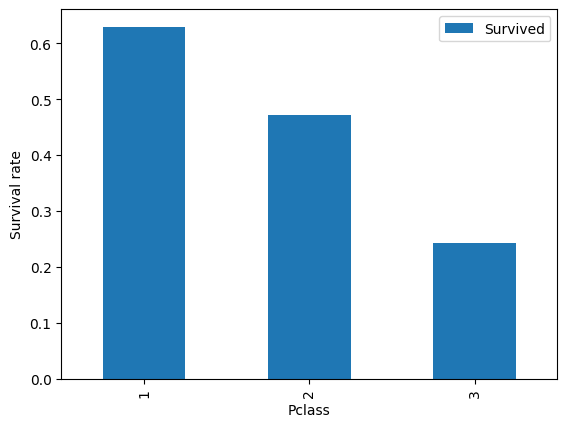

In [ ]:
ax = df.groupby('Pclass').agg({'Survived': 'mean'}).plot.bar()
ax.set_ylabel('Survival rate')
plt.show()

**Liczba pasażerów w klasach**

Analiza liczby pasażerów w poszczególnych klasach została wykonana w celu określenia struktury zbioru danych.

Pozwala to zrozumieć, jak rozkładają się dane pomiędzy klasami biletu i czy zbiór jest zbalansowany.

In [ ]:
df.groupby('Pclass').agg({'Name': 'count'})

,Name
Pclass,
1,216
2,184
3,491


Wizualizacja

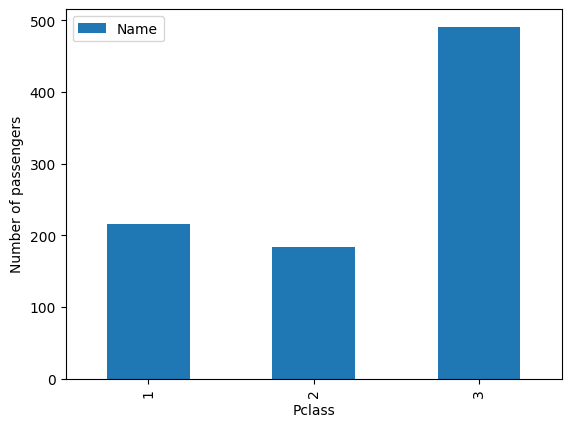

In [ ]:
ax = df.groupby('Pclass').agg({'Name': 'count'}).plot.bar()
ax.set_ylabel('Number of passengers')
plt.show()

**query (filtrowanie)**

Pasażerowie z klasy 1, którzy przeżyli

In [ ]:
df.query('Pclass == 1 and Survived == 1')[['Name', 'Age', 'Sex']]

,Name,Age,Sex
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,female
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female
11,"Bonnell, Miss. Elizabeth",58.0,female
23,"Sloper, Mr. William Thompson",28.0,male
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",NaN,female
...,...,...,...
862,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",48.0,female
871,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",47.0,female
879,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",56.0,female
887,"Graham, Miss. Margaret Edith",19.0,female


Filtrowanie danych zostało zastosowane w celu wyodrębnienia konkretnej grupy pasażerów (klasa 1, osoby które przeżyły).

Pozwala to na szczegółową analizę wybranych przypadków i badanie zależności w określonych podzbiorach danych.

## **b) realizacja eksperymentu (wyjaśnienie kroków eksperymentu)**

## **i. Definicja celu eksperymentu**

Celem eksperymentu jest zbudowanie i optymalizacja modelu uczenia maszynowego, który na podstawie cech pasażerów statku Titanic będzie przewidywał, czy dana osoba przeżyła katastrofę (Survived = 1) czy nie (Survived = 0).

W ramach eksperymentu zostanie przeprowadzony pełny proces uczenia maszynowego obejmujący:

- przygotowanie danych (data preprocessing),
- transformację zmiennych kategorycznych i numerycznych,
- budowę pipeline przetwarzającego dane,
- trenowanie modeli klasyfikacyjnych,
- ocenę jakości modelu przy użyciu walidacji krzyżowej,
- optymalizację hiperparametrów.

Główną metryką oceny jakości modelu będzie accuracy (dokładność klasyfikacji), ponieważ problem ma charakter klasyfikacji binarnej i zbiór danych nie jest silnie niezbalansowany po wstępnej analizie.

## **ii. Przygotowanie i przetwarzanie danych (data preprocessing)**

Na tym etapie dane zostają przygotowane do modelowania. Wykonane zostaną następujące kroki:

usunięcie kolumn nieistotnych dla modelu (np. identyfikatory, teksty),
uzupełnienie brakujących wartości,
kodowanie zmiennych kategorycznych,
podział zbioru na część treningową i testową.

Celem preprocessing jest przekształcenie danych do postaci numerycznej, która może być wykorzystana przez algorytmy uczenia maszynowego.

**Kopia danych i usunięcie niepotrzebnych kolumn**

In [ ]:
df_model = df.copy()

df_model = df_model.drop(columns=[
    'PassengerId',
    'Name',
    'Ticket',
    'Cabin'
])

In [ ]:
df_model

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


**Uzupełnianie braków danych**

In [ ]:
# uzupełnienie Age medianą
df_model['Age'] = df_model['Age'].fillna(df_model['Age'].median())

# uzupełnienie Embarked najczęstszą wartością
df_model['Embarked'] = df_model['Embarked'].fillna(df_model['Embarked'].mode()[0])

In [ ]:
df_model.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


**Kodowanie zmiennych kategorycznych**

In [ ]:
pd.get_dummies(df[['Sex', 'Embarked']])

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,False,True,False,False,True
1,True,False,True,False,False
2,True,False,False,False,True
3,True,False,False,False,True
4,False,True,False,False,True
...,...,...,...,...,...
886,False,True,False,False,True
887,True,False,False,False,True
888,True,False,False,False,True
889,False,True,True,False,False


In [ ]:
df_model = pd.get_dummies(df_model, columns=['Sex', 'Embarked'], drop_first=True)

In [ ]:
df_model

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,True,False,True
887,1,1,19.0,0,0,30.0000,False,False,True
888,0,3,28.0,1,2,23.4500,False,False,True
889,1,1,26.0,0,0,30.0000,True,False,False


In [ ]:
df_model.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

Dzięki temu:

- Sex → Sex_male
- Embarked → Embarked_Q, Embarked_S
(bez kolumny bazowej → unika dummy trap)

**Podział na X i y**

In [ ]:
X = df_model.drop(columns=['Survived'])
y = df_model['Survived']

**Podział na zbiór treningowy i testowy**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Po wykonaniu preprocessing dane zostały przekształcone do postaci numerycznej, co umożliwia zastosowanie algorytmów uczenia maszynowego.

Brakujące wartości zostały uzupełnione:

- zmienna `Age` została zastąpiona medianą,
- zmienna `Embarked` została uzupełniona najczęściej występującą kategorią.

Zmienne kategoryczne (Sex, Embarked) zostały zakodowane metodą one-hot encoding, co pozwala na ich wykorzystanie w modelach klasyfikacyjnych.

Następnie dane zostały podzielone na zbiór treningowy i testowy w proporcji 80/20 z zachowaniem proporcji klas (parametr stratify).

# **LogisticRegression**

## **iii. Budowa pipeline przetwarzania danych**

W celu uporządkowania procesu przetwarzania danych oraz trenowania modelu wykorzystano mechanizm pipeline dostępny w bibliotece scikit-learn.

Pipeline umożliwia połączenie wielu kroków (np. skalowania danych oraz modelowania) w jeden spójny proces, co zapewnia:

- większą czytelność kodu,
- eliminację błędów związanych z przetwarzaniem danych,
- możliwość łatwego wykorzystania walidacji krzyżowej.

Pipeline:


In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

In [ ]:
pipeline

Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

## **iv. Model i jego konfiguracja**

Jako model bazowy wykorzystano regresję logistyczną (Logistic Regression), która jest jednym z najczęściej stosowanych algorytmów w problemach klasyfikacji binarnej.

Model ten został wybrany ze względu na:

- prostotę interpretacji,
- dobrą wydajność dla danych tabelarycznych,
- możliwość wykorzystania jako punkt odniesienia dla bardziej zaawansowanych modeli.

Dane wejściowe zostały dodatkowo przeskalowane za pomocą StandardScaler, co poprawia stabilność i jakość działania modelu.

**Trenowanie modelu:**


In [ ]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

**Predykcja:**

In [ ]:
y_pred = pipeline.predict(X_test)

**Ocena modelu:**

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


## **v. Walidacja krzyżowa**

W celu dokładniejszej oceny jakości modelu zastosowano walidację krzyżową (cross-validation).

Metoda ta polega na wielokrotnym podziale danych na zbiory treningowe i walidacyjne, co pozwala uzyskać bardziej wiarygodną ocenę modelu niż pojedynczy podział na zbiór treningowy i testowy.

W projekcie zastosowano walidację krzyżową typu k-fold, gdzie dane dzielone są na k części (foldów), a model trenowany i oceniany jest k razy.

In [ ]:
cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores:", cv_scores)
print("Mean accuracy:", cv_scores.mean())

Cross-validation scores: [0.77094972 0.78651685 0.78089888 0.76966292 0.82022472]
Mean accuracy: 0.7856506182913816


Wyniki walidacji krzyżowej wskazują, że model osiąga stabilną skuteczność na poziomie około 0.78–0.82.

Niewielkie różnice pomiędzy poszczególnymi foldami sugerują, że model dobrze generalizuje i nie wykazuje oznak przeuczenia (overfittingu).

## **vi. Optymalizacja hiperparametrów**

W celu poprawy jakości modelu przeprowadzono optymalizację hiperparametrów z wykorzystaniem metody GridSearchCV.

Metoda ta polega na przeszukiwaniu przestrzeni możliwych parametrów modelu w celu znalezienia ich najlepszej kombinacji.

W eksperymencie optymalizowano parametry regresji logistycznej, takie jak:

- współczynnik regularyzacji (C),
- typ regularyzacji (penalty).

**Siatka parametrów**

In [ ]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

**GridSearch:**

In [ ]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

**Trenowanie**:

In [ ]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__penalty': ['l2'], 'model__solver': ['lbfgs']},
             scoring='accuracy')

**Wyniki**

In [ ]:
print("Best parameters:", grid_search.best_params_)
print("Best accuracy:", grid_search.best_score_)

Best parameters: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best accuracy: 0.8062444597655866


**Ocena na zbiorze testowym**

In [ ]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Test accuracy:", accuracy_score(y_test, y_pred_best))

Test accuracy: 0.8044692737430168


# **3. Dyskusja wyników dla LogisticRegression**

**a) Analiza miar**

W celu oceny jakości modelu wykorzystano metrykę accuracy, która mierzy odsetek poprawnie sklasyfikowanych obserwacji.

Model bazowy (Logistic Regression) osiągnął dokładność na poziomie około 0.80 na zbiorze testowym.

Zastosowanie walidacji krzyżowej pozwoliło potwierdzić stabilność modelu – średnia accuracy wyniosła około 0.79, przy niewielkich odchyleniach pomiędzy foldami.

Po przeprowadzeniu optymalizacji hiperparametrów za pomocą GridSearchCV uzyskano niewielką poprawę jakości modelu – accuracy wzrosło do około 0.81 w walidacji krzyżowej.

**b) Ocena realizacji celu**

Celem projektu było zbudowanie modelu klasyfikacyjnego przewidującego przeżycie pasażerów Titanica.

Cel ten został osiągnięty – model poprawnie klasyfikuje około 80% przypadków, co jest dobrym wynikiem dla tego typu danych.

Dodatkowo zastosowanie pipeline, walidacji krzyżowej oraz optymalizacji hiperparametrów pozwoliło na stworzenie kompletnego procesu uczenia maszynowego zgodnego z dobrymi praktykami.

**c) Interpretacja wyników**

Na podstawie przeprowadzonej analizy eksploracyjnej oraz wyników modelowania można stwierdzić, że:

płeć (Sex) ma bardzo istotny wpływ na przeżycie (kobiety miały większe szanse),
klasa biletu (Pclass) również odgrywa dużą rolę,
inne zmienne, takie jak wiek czy opłata za bilet, mają umiarkowany wpływ na wynik.

Model potwierdził zależności zaobserwowane wcześniej podczas analizy danych.

**d) Możliwe ulepszenia**

W przyszłości model można ulepszyć poprzez:

- zastosowanie bardziej zaawansowanych algorytmów (np. Random Forest, XGBoost),
- lepszą imputację brakujących danych (np. modele predykcyjne dla Age),
- inżynierię cech (feature engineering), np. tworzenie nowych zmiennych,
- analizę innych metryk (precision, recall, F1-score).

# **4. Model alternatywny – Random Forest**

**Pipeline:**

In [ ]:
rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

In [ ]:
rf_pipeline

Pipeline(steps=[('model', RandomForestClassifier(random_state=42))])

**Trenowanie:**

In [ ]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('model', RandomForestClassifier(random_state=42))])

**Predykcja:**

In [ ]:
y_pred_rf = rf_pipeline.predict(X_test)

**Ocena modelu:**

In [ ]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest accuracy:", rf_accuracy)

Random Forest accuracy: 0.8156424581005587


**Cross-validation:**

In [ ]:
rf_cv = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("RF CV scores:", rf_cv)
print("RF mean accuracy:", rf_cv.mean())

RF CV scores: [0.79888268 0.81460674 0.84831461 0.78651685 0.82022472]
RF mean accuracy: 0.813709120582512


**Hyperparameter tuning**

**Siatka parametrów:**

In [ ]:
rf_param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5],
}

**GridSearch:**

In [ ]:
rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

**Trenowanie:**

In [ ]:
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [50, 100, 200]},
             scoring='accuracy')

**Wyniki:**

In [ ]:
print("RF best params:", rf_grid.best_params_)
print("RF best CV accuracy:", rf_grid.best_score_)

RF best params: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
RF best CV accuracy: 0.8217275682064414


**Ocena na zbiorze testowym:**

In [ ]:
best_rf = rf_grid.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

print("RF test accuracy:", accuracy_score(y_test, y_pred_best_rf))

RF test accuracy: 0.8044692737430168


# **5. Porównanie modeli**

Można zauważyć, że model Random Forest osiąga porównywalną lub lepszą jakość predykcji niż regresja logistyczna.

Model ten lepiej radzi sobie z nieliniowymi zależnościami w danych, jednak jego interpretacja jest trudniejsza.

In [ ]:
results.style.format({
    'CV accuracy': '{:.3f}',
    'Test accuracy': '{:.3f}'
})

,Model,CV accuracy,Test accuracy
0,Logistic Regression,0.786,0.804
1,Random Forest,0.814,0.804


Model Random Forest osiągnął wyższą średnią skuteczność w walidacji krzyżowej (około 0.814) w porównaniu do regresji logistycznej.

Jednocześnie oba modele osiągnęły bardzo podobną jakość na zbiorze testowym (około 0.80), co sugeruje, że:

- dane mają ograniczoną złożoność,
- prostszy model liniowy jest już wystarczająco skuteczny,
- Random Forest lepiej dopasowuje się do danych treningowych, ale nie daje dużej poprawy generalizacji.

# **6. Finalny wniosek**

Oba modele osiągnęły porównywalne wyniki (~0.80 accuracy), jednak Random Forest wykazał nieco lepszą skuteczność w walidacji krzyżowej.

Ostatecznie wybór modelu zależy od priorytetu:

-  interpretowalność → regresja logistyczna,
- wydajność i złożoność danych → Random Forest.